In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
cs_df = pd.read_csv("data_pelanggan.csv")
product_df = pd.read_csv("data_produk.csv")
transaction_df = pd.read_csv("data_transaksi.csv")

In [3]:
cs_df.head()

,customer_id,nama_pelanggan,jumlah_pembelian,terakhir_beli,feedback
0,CORP-01,PT Makanan Sehat,10,2025-08-17,Akan menjadi langganan tetap.
1,CORP-02,CV Minuman Segar,7,2025-08-11,Harga sangat kompetitif.
2,CORP-03,UMKM Dapur Bunda,14,2025-08-18,Pengiriman selalu tepat waktu.
3,CORP-04,Kopi Kita Bersama,9,2025-08-18,Kualitas produk konsisten.
4,CORP-05,Pabrik Keripik Renyah,10,2025-08-15,Kualitas produk konsisten.


In [4]:
product_df.head()

,product_id,nama_produk,kategori,harga_satuan,stok
0,PKG-BTL-01,Botol PET Bening 500ml,Kemasan Primer,1200,50000
1,PKG-BOX-01,Karton Box Die Cut 20x15x8,Kemasan Sekunder,3100,15000
2,PKG-TRY-01,Tray Makanan Mika 4 Sekat,Kemasan Primer,800,75000
3,PKG-PCH-01,Standing Pouch Aluminium 250g,Kemasan Primer,1500,40000
4,PKG-LBL-01,Stiker Label Vinyl Tahan Air,Komponen,350,250000


In [5]:
transaction_df.head()

,order_id,tanggal,reseller_id,customer_id,product_id,qty,harga,margin
0,PO-2508-001,2025-07-31,RESL-A,CORP-05,PKG-BOX-02,1000,2800000,6.155512e+05
1,PO-2508-002,2025-08-08,RESL-A,CORP-07,PKG-PCH-01,2000,3000000,4.764951e+05
2,PO-2508-003,2025-08-03,RESL-C,CORP-03,PKG-PCH-01,7500,11250000,1.983238e+06
3,PO-2508-004,2025-07-01,RESL-C,CORP-04,PKG-PCH-01,2500,3750000,6.572688e+05
4,PO-2508-005,2025-08-17,RESL-C,CORP-04,PKG-TRY-01,2000,1600000,3.128841e+05


#### Hubungan
transaksi mirip dengan relasi data many to many antara data reseller, cs, dan produk.

In [7]:
cs_df.info()
product_df.info()
transaction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       12 non-null     object
 1   nama_pelanggan    12 non-null     object
 2   jumlah_pembelian  12 non-null     int64 
 3   terakhir_beli     12 non-null     object
 4   feedback          12 non-null     object
dtypes: int64(1), object(4)
memory usage: 612.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    8 non-null      object
 1   nama_produk   8 non-null      object
 2   kategori      8 non-null      object
 3   harga_satuan  8 non-null      int64 
 4   stok          8 non-null      int64 
dtypes: int64(2), object(3)
memory usage: 452.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
D

### Rekomendasi Produk ke Pelanggan (Personal)

In [11]:
# Membuat User-Item Matrix
# Kita menjumlahkan total 'qty' untuk setiap kombinasi customer_id dan product_id
user_item_matrix = transaction_df.pivot_table(
    index='customer_id', 
    columns='product_id', 
    values='qty', 
    aggfunc='sum'
).fillna(0)

print("Ukuran User-Item Matrix:", user_item_matrix.shape)
user_item_matrix.head()

Ukuran User-Item Matrix: (12, 8)


product_id,PKG-BOX-01,PKG-BOX-02,PKG-BTL-01,PKG-BTL-02,PKG-CAP-01,PKG-LBL-01,PKG-PCH-01,PKG-TRY-01
customer_id,,,,,,,,
CORP-01,5000.0,2500.0,8000.0,0.0,0.0,3000.0,10000.0,10000.0
CORP-02,7500.0,2000.0,10000.0,5000.0,0.0,0.0,15000.0,2000.0
CORP-03,0.0,2000.0,18500.0,13000.0,10000.0,9500.0,15000.0,2500.0
CORP-04,1000.0,0.0,7000.0,0.0,2000.0,500.0,7500.0,7000.0
CORP-05,0.0,8500.0,15000.0,7500.0,2500.0,1000.0,9500.0,500.0


In [12]:
# Menghitung Cosine Similarity antar Pelanggan
# Ini akan mengukur seberapa mirip preferensi belanja antar satu user dengan user lainnya
user_sim = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_sim, index=user_item_matrix.index, columns=user_item_matrix.index)
user_sim_df.head(13)

customer_id,CORP-01,CORP-02,CORP-03,CORP-04,CORP-05,CORP-06,CORP-07,CORP-08,CORP-09,CORP-10,CORP-11,CORP-12
customer_id,,,,,,,,,,,,
CORP-01,1.000000,0.823909,0.667778,0.941938,0.659190,0.546397,0.658491,0.131300,0.054918,0.279204,0.128728,0.716083
CORP-02,0.823909,1.000000,0.776966,0.793631,0.804895,0.646013,0.703339,0.212886,0.284580,0.320985,0.240699,0.859691
CORP-03,0.667778,0.776966,1.000000,0.735374,0.877091,0.410227,0.584992,0.596609,0.580836,0.521992,0.500200,0.830272
CORP-04,0.941938,0.793631,0.735374,1.000000,0.690509,0.411625,0.609206,0.289169,0.115538,0.219849,0.016163,0.818486
CORP-05,0.659190,0.804895,0.877091,0.690509,1.000000,0.640429,0.677068,0.380261,0.449371,0.510244,0.470849,0.852839
CORP-06,0.546397,0.646013,0.410227,0.411625,0.640429,1.000000,0.372289,0.067744,0.063661,0.285277,0.359922,0.441917
CORP-07,0.658491,0.703339,0.584992,0.609206,0.677068,0.372289,1.000000,0.289611,0.135463,0.142953,0.068957,0.665668
CORP-08,0.131300,0.212886,0.596609,0.289169,0.380261,0.067744,0.289611,1.000000,0.621897,0.301451,0.277969,0.296593
CORP-09,0.054918,0.284580,0.580836,0.115538,0.449371,0.063661,0.135463,0.621897,1.000000,0.846771,0.773047,0.170310


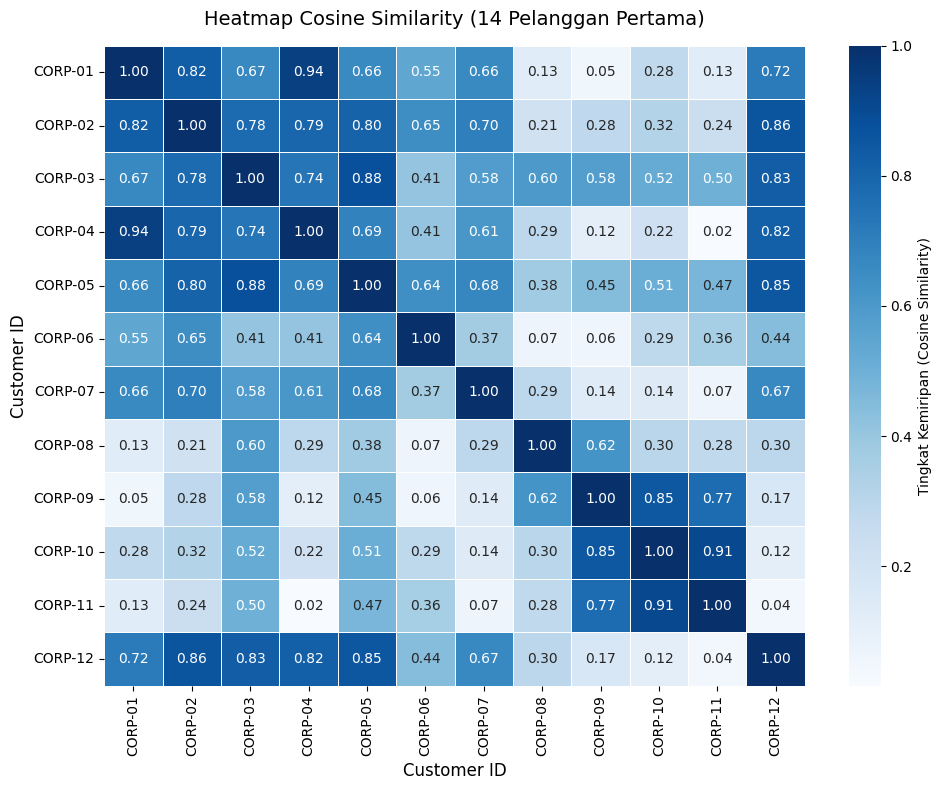

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

subset_sim_df = user_sim_df.iloc[:14, :14]
plt.figure(figsize=(10, 8))

# Membuat heatmap
sns.heatmap(
    subset_sim_df, 
    annot=True,          # Menampilkan angka di dalam kotak
    cmap='Blues',        # Skala warna (bisa diganti 'YlGnBu', 'coolwarm', dll)
    fmt=".2f",           # Membulatkan angka menjadi 2 desimal
    linewidths=0.5,      # Memberi garis pembatas antar kotak
    cbar_kws={'label': 'Tingkat Kemiripan (Cosine Similarity)'}
)

# Menambahkan judul dan label
plt.title('Heatmap Cosine Similarity (14 Pelanggan Pertama)', fontsize=14, pad=15)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)

# Menampilkan grafik
plt.tight_layout()
plt.show()

In [13]:
# Membuat Fungsi Rekomendasi
def dapatkan_rekomendasi_produk(target_customer, top_n=2):
    """
    Fungsi untuk memberikan rekomendasi produk yang belum pernah dibeli 
    oleh target_customer berdasarkan kemiripan dengan pelanggan lain.
    """
    if target_customer not in user_item_matrix.index:
        # Pendekatan Fallback: Jika pelanggan baru/belum ada transaksi, berikan produk terlaris keseluruhan
        top_products = transaction_df.groupby('product_id')['qty'].sum().sort_values(ascending=False).head(top_n).index
        return product_df[product_df['product_id'].isin(top_products)][['product_id', 'nama_produk', 'kategori']]
    
    # Cari pelanggan yang paling mirip (selain dirinya sendiri)
    pelanggan_mirip = user_sim_df[target_customer].sort_values(ascending=False).index[1]
    # Ambil produk yang dibeli oleh pelanggan yang mirip tersebut
    produk_pelanggan_mirip = user_item_matrix.loc[pelanggan_mirip]
    # Ambil riwayat produk yang sudah dibeli oleh target pelanggan
    produk_target_pelanggan = user_item_matrix.loc[target_customer]
    
    # Filter: Cari produk yang dibeli pelanggan mirip tetapi BELUM dibeli target pelanggan
    kandidat_rekomendasi = produk_pelanggan_mirip[(produk_pelanggan_mirip > 0) & (produk_target_pelanggan == 0)]
    # Jika tidak ada kandidat unik, ambil produk dengan pembelian tertinggi dari pelanggan mirip
    if kandidat_rekomendasi.empty:
        kandidat_rekomendasi = produk_pelanggan_mirip[produk_pelanggan_mirip > 0]        
    # Ambil ID Produk teratas
    id_produk_rekomendasi = kandidat_rekomendasi.sort_values(ascending=False).head(top_n).index.tolist()

    # Gabungkan dengan product_df untuk mendapatkan informasi detail produk
    hasil_df = product_df[product_df['product_id'].isin(id_produk_rekomendasi)][['product_id', 'nama_produk', 'kategori']]
    return hasil_df


In [14]:
# --- UJI COBA FUNGSI REKOMENDASI ---
# Mengambil salah satu contoh customer_id secara dinamis dari data Anda
contoh_customer = cs_df['customer_id'].iloc[0]
rekomendasi_user = dapatkan_rekomendasi_produk(target_customer=contoh_customer, top_n=5)

print(f"\nRekomendasi Produk untuk Pelanggan ID ({contoh_customer}):")
print(rekomendasi_user)


Rekomendasi Produk untuk Pelanggan ID (CORP-01):
   product_id            nama_produk  kategori
6  PKG-CAP-01  Tutup Botol Ulir 28mm  Komponen


#### Visualisasi Tren dan Pembelian

In [32]:
transaction_df.head()

,order_id,tanggal,reseller_id,customer_id,product_id,qty,harga,margin
0,PO-2508-001,2025-07-31,RESL-A,CORP-05,PKG-BOX-02,1000,2800000,6.155512e+05
1,PO-2508-002,2025-08-08,RESL-A,CORP-07,PKG-PCH-01,2000,3000000,4.764951e+05
2,PO-2508-003,2025-08-03,RESL-C,CORP-03,PKG-PCH-01,7500,11250000,1.983238e+06
3,PO-2508-004,2025-07-01,RESL-C,CORP-04,PKG-PCH-01,2500,3750000,6.572688e+05
4,PO-2508-005,2025-08-17,RESL-C,CORP-04,PKG-TRY-01,2000,1600000,3.128841e+05


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter

# Pastikan kolom tanggal berformat datetime
transaction_df['tanggal'] = pd.to_datetime(transaction_df['tanggal'])

# VISUALISASI TREN PEMBELIAN HARIAN
tren_harian = transaction_df.groupby('tanggal')['qty'].sum().reset_index()
tren_harian.head()


,tanggal,qty
0,2025-07-01,3500
1,2025-07-02,10000
2,2025-07-03,10000
3,2025-07-04,7000
4,2025-07-05,13000


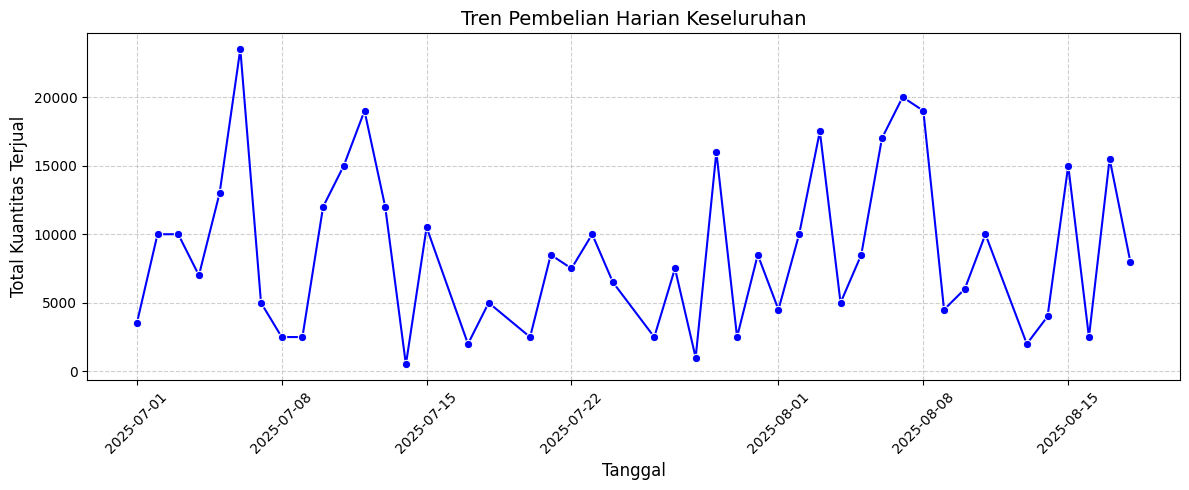

In [37]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=tren_harian, x='tanggal', y='qty', marker='o', color='b')
plt.title('Tren Pembelian Harian Keseluruhan', fontsize=14)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Kuantitas Terjual', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [17]:

# ---------------------------------------------------------
# ASOSIASI PRODUK (Produk yang sering dibeli bersamaan)
# ---------------------------------------------------------
transaction_merged_df = pd.merge(
    transaction_df, 
    product_df[['product_id', 'nama_produk', 'kategori']], # Mengambil kolom yang diperlukan saja
    on='product_id', 
    how='left' # Left join: mempertahankan semua baris transaksi
)
# Mengelompokkan produk berdasarkan order_id
order_produk = transaction_merged_df.groupby('order_id')['nama_produk'].apply(list).reset_index()
order_produk

,order_id,nama_produk
0,PO-2508-001,[Dus Produk Glossy 10x10x10]
1,PO-2508-002,[Standing Pouch Aluminium 250g]
2,PO-2508-003,[Standing Pouch Aluminium 250g]
3,PO-2508-004,[Standing Pouch Aluminium 250g]
4,PO-2508-005,[Tray Makanan Mika 4 Sekat]
...,...,...
95,PO-2508-096,[Standing Pouch Aluminium 250g]
96,PO-2508-097,[Stiker Label Vinyl Tahan Air]
97,PO-2508-098,[Tray Makanan Mika 4 Sekat]
98,PO-2508-099,[Standing Pouch Aluminium 250g]


In [19]:
# Menghitung kombinasi 2 produk yang sering muncul bersama
kombinasi_produk = Counter()
for produk_list in order_produk['nama_produk']:
    if len(produk_list) > 1:
        # Mencari semua kombinasi berpasangan dalam 1 transaksi
        kombinasi_produk.update(combinations(sorted(produk_list), 2))

# Mengubah hasil ke DataFrame
asosiasi_df = pd.DataFrame(kombinasi_produk.most_common(5), columns=['Pasangan Produk', 'Frekuensi'])
print("Top 5 Pasangan Produk yang Sering Dibeli Bersamaan:")
print(asosiasi_df)

Top 5 Pasangan Produk yang Sering Dibeli Bersamaan:
Empty DataFrame
Columns: [Pasangan Produk, Frekuensi]
Index: []


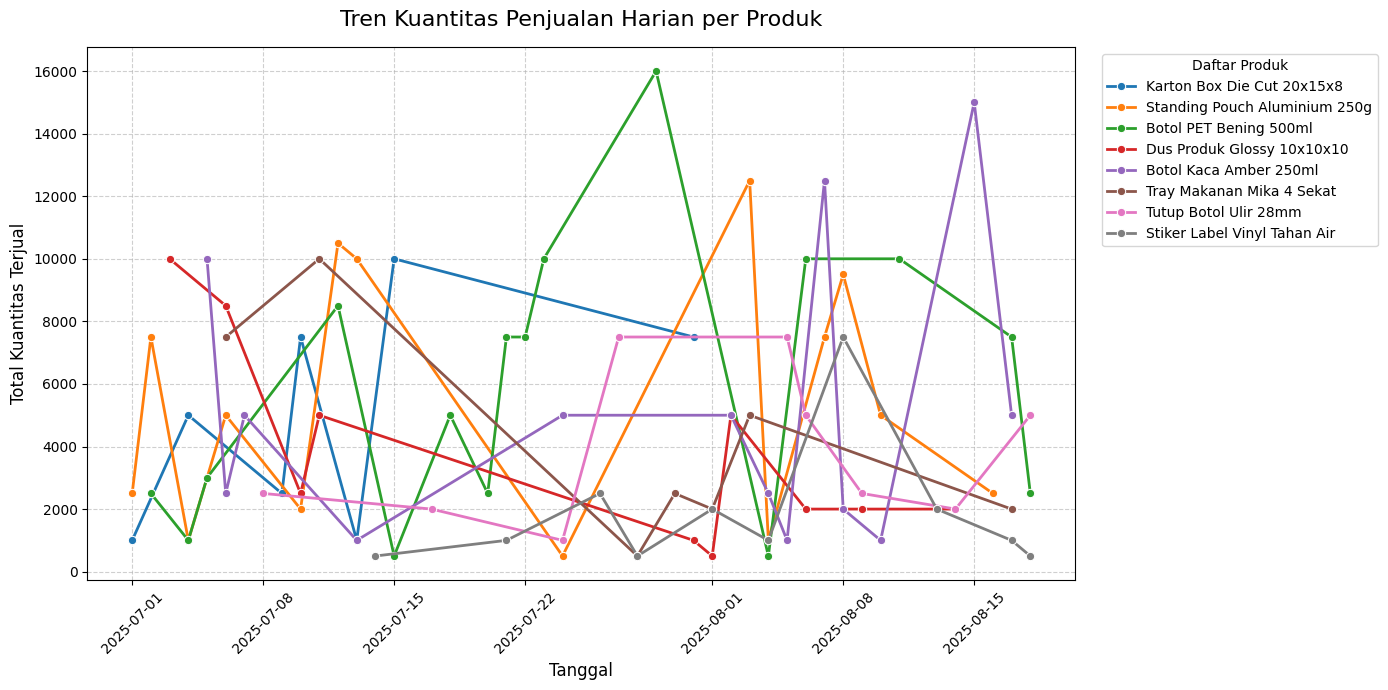

In [44]:
# Kita menjumlahkan qty agar jika ada transaksi produk yang sama di hari yang sama, totalnya tergabung
tren_produk_harian = transaction_merged_df.groupby(['tanggal', 'nama_produk'])['qty'].sum().reset_index()

plt.figure(figsize=(14, 7))
# Menggunakan sns.lineplot dengan parameter 'hue' untuk memisahkan warna garis per produk
sns.lineplot(
    data=tren_produk_harian, 
    x='tanggal', 
    y='qty', 
    hue='nama_produk', 
    marker='o',       # Menambahkan titik pada setiap data untuk memperjelas
    linewidth=2       # Ketebalan garis
)
plt.title('Tren Kuantitas Penjualan Harian per Produk', fontsize=16, pad=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Kuantitas Terjual', fontsize=12)

# Mengatur kemiringan teks tanggal di sumbu X agar tidak bertumpuk
plt.xticks(rotation=45)

# Mengatur posisi Legenda agar berada di luar grafik (sebelah kanan) agar tidak menutupi garis
plt.legend(title='Daftar Produk', bbox_to_anchor=(1.02, 1), loc='upper left')

# Menambahkan grid untuk memudahkan pembacaan titik data
plt.grid(True, linestyle='--', alpha=0.6)

# Mencegah ada bagian grafik yang terpotong
plt.tight_layout()

# Tampilkan grafik
plt.show()

### Segmentasi Pelanggan RFM Analysis

In [45]:
# ---------------------------------------------------------
# 2. SEGMENTASI PELANGGAN & REKOMENDASI PROMO
# ---------------------------------------------------------

# Hitung total pengeluaran (Monetary) dari transaksi
monetary_df = transaction_df.groupby('customer_id')['harga'].sum().reset_index()
monetary_df.rename(columns={'harga': 'total_belanja'}, inplace=True)

# Gabungkan dengan data pelanggan
rfm_df = pd.merge(
    cs_df, 
    monetary_df, 
    on='customer_id', 
    how='left'
).fillna(0)

# Pastikan format 'terakhir_beli' adalah datetime
rfm_df['terakhir_beli'] = pd.to_datetime(rfm_df['terakhir_beli'])

# Tentukan tanggal acuan (misalnya tanggal transaksi terakhir + 1 hari)
tanggal_acuan = transaction_df['tanggal'].max() + pd.Timedelta(days=1)

# Hitung Recency (Berapa hari sejak pembelian terakhir)
rfm_df['recency_hari'] = (tanggal_acuan - rfm_df['terakhir_beli']).dt.days

rfm_df.head()


,customer_id,nama_pelanggan,jumlah_pembelian,terakhir_beli,feedback,total_belanja,recency_hari
0,CORP-01,PT Makanan Sehat,10,2025-08-17,Akan menjadi langganan tetap.,56150000,2
1,CORP-02,CV Minuman Segar,7,2025-08-11,Harga sangat kompetitif.,77450000,8
2,CORP-03,UMKM Dapur Bunda,14,2025-08-18,Pengiriman selalu tepat waktu.,90625000,1
3,CORP-04,Kopi Kita Bersama,9,2025-08-18,Kualitas produk konsisten.,29025000,1
4,CORP-05,Pabrik Keripik Renyah,10,2025-08-15,Kualitas produk konsisten.,76175000,4


In [46]:
def tentukan_segmen(row):
    """
    Logika segmentasi sederhana:
    - New Customer: Baru beli 1 kali.
    - Loyal Customer: Beli > 3 kali dan recency <= 30 hari.
    - At Risk: Sudah lama tidak beli (recency > 30 hari).
    - Regular: Di luar kondisi di atas.
    """
    if row['jumlah_pembelian'] == 1:
        return 'New Customer'
    elif row['recency_hari'] > 30:
        return 'At Risk'
    elif row['jumlah_pembelian'] > 3 and row['recency_hari'] <= 30:
        return 'Loyal Customer'
    else:
        return 'Regular Customer'

rfm_df['segmen'] = rfm_df.apply(tentukan_segmen, axis=1)

# Fungsi Rekomendasi Promosi
def rekomendasi_promo(segmen):
    if segmen == 'Loyal Customer':
        return 'Upsell/Cross-sell promo eksklusif, Program Poin'
    elif segmen == 'At Risk':
        return 'Voucher Diskon Win-Back, Email pengingat rindu'
    elif segmen == 'New Customer':
        return 'Diskon pembelian kedua, Edukasi penggunaan produk'
    else:
        return 'Promo Bundling standar'

rfm_df['rekomendasi_promo'] = rfm_df['segmen'].apply(rekomendasi_promo)

print("--- Hasil Segmentasi Pelanggan ---")
print(rfm_df[['customer_id', 'segmen', 'rekomendasi_promo']])

--- Hasil Segmentasi Pelanggan ---
   customer_id            segmen  \
0      CORP-01    Loyal Customer   
1      CORP-02    Loyal Customer   
2      CORP-03    Loyal Customer   
3      CORP-04    Loyal Customer   
4      CORP-05    Loyal Customer   
5      CORP-06           At Risk   
6      CORP-07    Loyal Customer   
7      CORP-08    Loyal Customer   
8      CORP-09    Loyal Customer   
9      CORP-10    Loyal Customer   
10     CORP-11  Regular Customer   
11     CORP-12    Loyal Customer   

                                  rekomendasi_promo  
0   Upsell/Cross-sell promo eksklusif, Program Poin  
1   Upsell/Cross-sell promo eksklusif, Program Poin  
2   Upsell/Cross-sell promo eksklusif, Program Poin  
3   Upsell/Cross-sell promo eksklusif, Program Poin  
4   Upsell/Cross-sell promo eksklusif, Program Poin  
5    Voucher Diskon Win-Back, Email pengingat rindu  
6   Upsell/Cross-sell promo eksklusif, Program Poin  
7   Upsell/Cross-sell promo eksklusif, Program Poin  
8   Upsell

### Forecast Stok (1 Produk) & Safety Stock

In [29]:
# ---------------------------------------------------------
# 3. FORECAST STOK & SAFETY STOCK (Produk Terlaris)
# ---------------------------------------------------------

# Pilih 1 produk dengan penjualan tertinggi
top_product_id = transaction_df.groupby('product_id')['qty'].sum().idxmax()
nama_top_produk = product_df.loc[product_df['product_id'] == top_product_id, 'nama_produk'].values[0]

print(f"\nMelakukan analisis untuk Produk Terlaris: {nama_top_produk} ({top_product_id})")

# Saring transaksi hanya untuk produk ini
df_prod = transaction_df[transaction_df['product_id'] == top_product_id].copy()

# Agregasi penjualan harian
sales_harian = df_prod.groupby('tanggal')['qty'].sum().reset_index()
sales_harian = sales_harian.set_index('tanggal').asfreq('D', fill_value=0) # Isi tanggal kosong dengan 0

# A. Forecast: Simple Moving Average (SMA) 7 hari
sales_harian['SMA_7'] = sales_harian['qty'].rolling(window=7).mean().round(2)
prediksi_besok = sales_harian['SMA_7'].iloc[-1] # Nilai MA di hari terakhir sebagai prediksi besok

# B. Safety Stock (Asumsi Lead Time Supplier)
avg_lead_time = 3 # Rata-rata hari supplier mengirim barang
max_lead_time = 5 # Waktu terlama pengiriman barang

max_daily_sales = sales_harian['qty'].max()
avg_daily_sales = sales_harian['qty'].mean()

safety_stock = (max_daily_sales * max_lead_time) - (avg_daily_sales * avg_lead_time)

# C. Titik Pemesanan Kembali (Reorder Point / ROP)
# ROP = Demand selama Lead Time + Safety Stock
rop = (avg_daily_sales * avg_lead_time) + safety_stock

print("-" * 50)
print(f"Prediksi Permintaan Harian ke depan (SMA 7-hari) : {prediksi_besok} unit")
print(f"Rekomendasi Safety Stock                         : {int(np.ceil(safety_stock))} unit")
print(f"Reorder Point (ROP - Kapan harus pesan lagi)     : {int(np.ceil(rop))} unit")
print("-" * 50)


Melakukan analisis untuk Produk Terlaris: Botol PET Bening 500ml (PKG-BTL-01)
--------------------------------------------------
Prediksi Permintaan Harian ke depan (SMA 7-hari) : 1428.57 unit
Rekomendasi Safety Stock                         : 74094 unit
Reorder Point (ROP - Kapan harus pesan lagi)     : 80000 unit
--------------------------------------------------
